# Session 6: Bayesian Computation — From Metropolis to PyMC & NUTS

**Bayesian Analysis of Empirical Data (2026)**  
*Author: Irina Knyazeva*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iknyazeva/bayes-cogsci-book/blob/main/notebooks/colab/06_bayesian_computation.ipynb)

In realistic empirical research, the normalizing denominator in Bayes' rule—the marginal likelihood $p(y) = \int p(y \mid \theta) p(\theta) d\theta$—is an intractable high-dimensional integral. We cannot solve it analytically, nor can we use naive rejection sampling.

This laboratory notebook guides you through the computational ladder of modern Bayesian statistics:
1. **Direct Monte Carlo vs. MCMC**: Independent draws vs. dependent Markov chains.
2. **Metropolis–Hastings from Scratch**: Building an unnormalized posterior sampler in 15 lines of Python.
3. **The Step-Size Tuning Dilemma**: Discovering why proposal scale controls the tradeoff between acceptance rate and exploration speed.
4. **The 2D Correlated Ridge Problem**: Why random-walk proposals break down in correlated parameter spaces (motivating physics-guided gradients).
5. **The Canonical PyMC/NUTS Benchmark**: Validating Hamiltonian Monte Carlo against the exact closed-form $\operatorname{Beta}(50, 34)$ conjugate posterior.
6. **The Minimum Computational Diagnostic Gate**: Auditing $\widehat{R}$, bulk/tail ESS, rank plots, and divergences before drawing substantive conclusions.

In [1]:
# Setup dependencies and clean plotting aesthetics
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
import pymc as pm

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "font.family": "sans-serif",
    "figure.titlesize": 14,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.autolayout": True
})
rng = np.random.default_rng(2026)
print("PyMC version:", pm.__version__)
print("ArviZ version:", az.__version__)

PyMC version: 5.28.0
ArviZ version: 0.23.4


---
## 1. Direct Monte Carlo vs. MCMC: Integration by Simulation

When independent draws $\theta^{(1)}, \dots, \theta^{(S)}$ can be sampled directly from a posterior distribution $p(\theta \mid y)$, any posterior expectation $\mathbb{E}[g(\theta) \mid y]$ is estimated by the empirical sample average:

$$\widehat{\mathbb{E}}[g(\theta)] = \frac{1}{S} \sum_{s=1}^S g(\theta^{(s)}).$$

The numerical accuracy of this finite simulation is quantified by the **Monte Carlo Standard Error (MCSE)**:

$$\operatorname{MCSE}(\bar{g}) = \frac{\operatorname{SD}(g(\theta))}{\sqrt{S}}.$$

```{important}
**Posterior Uncertainty vs. Monte Carlo Error:**  
* **Posterior Credible Interval**: Reflects genuine scientific uncertainty about $\theta$ given the finite empirical data $y$ and prior.
* **MCSE**: Measures only our computational simulation noise. Increasing draws $S \to 4S$ halves MCSE, but does NOT make the posterior narrower!
```

In [2]:
# Exact conjugate benchmark from Session 4: Beta(2, 2) + Binomial(80, 48) -> Beta(50, 34)
alpha_post, beta_post = 50, 34
exact_mean = alpha_post / (alpha_post + beta_post)  # 50 / 84 ≈ 0.5952
exact_sd = np.sqrt((alpha_post * beta_post) / ((alpha_post + beta_post)**2 * (alpha_post + beta_post + 1)))
exact_hdi = stats.beta.ppf([0.025, 0.975], alpha_post, beta_post)

# Draw S = 4,000 independent Monte Carlo samples
S = 4000
direct_draws = rng.beta(alpha_post, beta_post, size=S)

mc_mean = np.mean(direct_draws)
mcse = np.std(direct_draws, ddof=1) / np.sqrt(S)

print(f"Exact Closed-Form Mean: {exact_mean:.5f}")
print(f"Direct Monte Carlo Mean: {mc_mean:.5f} ± {mcse:.5f} (MCSE)")
print(f"Exact 95% Interval:      [{exact_hdi[0]:.4f}, {exact_hdi[1]:.4f}]")
print(f"Sampled 95% Quantiles:   [{np.percentile(direct_draws, 2.5):.4f}, {np.percentile(direct_draws, 97.5):.4f}]")

Exact Closed-Form Mean: 0.59524
Direct Monte Carlo Mean: 0.59399 ± 0.00084 (MCSE)
Exact 95% Interval:      [0.4890, 0.6972]
Sampled 95% Quantiles:   [0.4875, 0.6968]


---
## 2. Building a Metropolis–Hastings Sampler from Scratch

In complex models, we cannot draw independent samples because the normalizing denominator $p(y)$ is unknown. However, we can evaluate the **unnormalized posterior**:

$$\widetilde{p}(\theta \mid y) = p(y \mid \theta) p(\theta).$$

The **Metropolis–Hastings algorithm** constructs a Markov chain whose stationary distribution is exactly the target posterior:
1. From current state $\theta^{(t)}$, propose candidate $\theta^* \sim q(\theta^* \mid \theta^{(t)})$.
2. Compute the acceptance ratio:
   $$\alpha = \min\left(1, \; \frac{\widetilde{p}(\theta^* \mid y)}{\widetilde{p}(\theta^{(t)} \mid y)} \cdot \frac{q(\theta^{(t)} \mid \theta^*)}{q(\theta^* \mid \theta^{(t)})}\right).$$
   For symmetric proposals ($q(\theta^* \mid \theta) = q(\theta \mid \theta^*)$), proposal probabilities cancel!
3. Draw $u \sim \operatorname{Uniform}(0, 1)$. If $u < \alpha$, accept $\theta^{(t+1)} = \theta^*$; otherwise reject and repeat the current state $\theta^{(t+1)} = \theta^{(t)}$.

In [3]:
def unnormalized_log_posterior(theta, y=48, n=80, a_prior=2, b_prior=2):
    """Log joint density log p(y, theta) = log p(y | theta) + log p(theta)."""
    if theta <= 0.0 or theta >= 1.0:
        return -np.inf  # Parameter space boundary
    log_prior = stats.beta.logpdf(theta, a_prior, b_prior)
    log_like = stats.binom.logpmf(y, n, theta)
    return log_prior + log_like

def run_metropolis(log_target_func, theta_start, n_draws, prop_sd, seed=2026):
    """A complete 15-line random-walk Metropolis sampler."""
    gen = np.random.default_rng(seed)
    chain = np.zeros(n_draws)
    current_theta = theta_start
    current_logp = log_target_func(current_theta)
    accepted_count = 0
    
    for t in range(n_draws):
        # Propose candidate from Gaussian random walk
        proposal = current_theta + gen.normal(0, prop_sd)
        prop_logp = log_target_func(proposal)
        
        # Log-acceptance ratio
        log_alpha = prop_logp - current_logp
        if np.log(gen.uniform(0, 1)) < log_alpha:
            current_theta = proposal
            current_logp = prop_logp
            accepted_count += 1
            
        chain[t] = current_theta
        
    acceptance_rate = accepted_count / n_draws
    return chain, acceptance_rate

print("Metropolis sampler function compiled successfully!")

Metropolis sampler function compiled successfully!


---
## 3. The Step-Size Tuning Experiment

In random-walk Metropolis, the proposal standard deviation $\sigma_{\text{prop}}$ controls chain efficiency:
* **Too Small ($\sigma = 0.01$)**: Proposals are accepted nearly every time ($> 95\%$), but the chain explores via agonizingly slow Brownian diffusion.
* **Too Large ($\sigma = 2.50$)**: Most proposals land in extreme low-density regions, resulting in high rejection rates ($> 95\%$) and long periods of "sticking".
* **Tuned ($\sigma = 0.15$)**: Balances movement with acceptance (optimal 1D rate $\approx 44\%$).

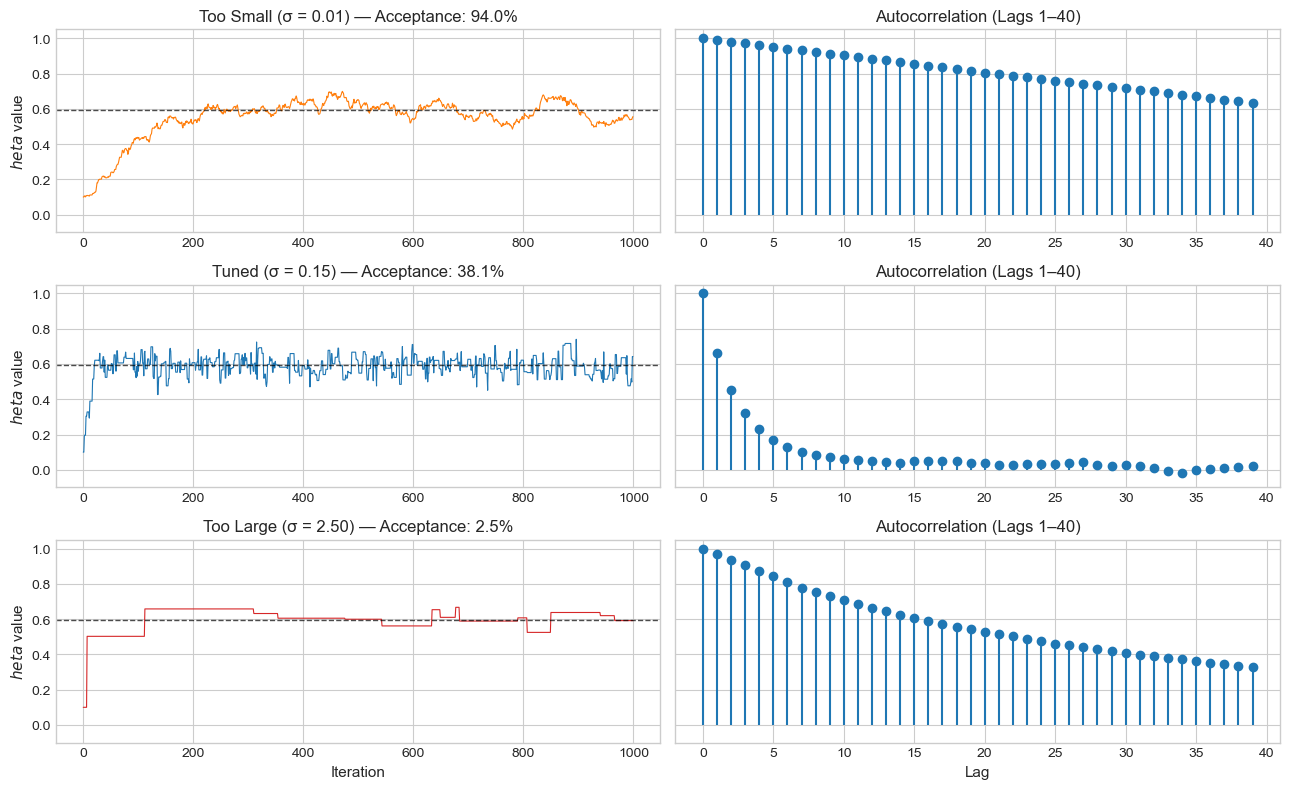

In [4]:
N_DRAWS = 5000
scales = [0.01, 0.15, 2.5]
labels = ["Too Small (σ = 0.01)", "Tuned (σ = 0.15)", "Too Large (σ = 2.50)"]
chains = []
acc_rates = []

for s in scales:
    c, acc = run_metropolis(unnormalized_log_posterior, theta_start=0.1, n_draws=N_DRAWS, prop_sd=s)
    chains.append(c)
    acc_rates.append(acc)

fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharey="row")

for i, (chain, acc, label) in enumerate(zip(chains, acc_rates, labels)):
    # Trace plot (first 1000 draws)
    axes[i, 0].plot(chain[:1000], lw=0.8, color="tab:blue" if i==1 else ("tab:orange" if i==0 else "tab:red"))
    axes[i, 0].axhline(exact_mean, color="black", ls="--", lw=1, alpha=0.7, label="Exact Mean")
    axes[i, 0].set_title(f"{label} — Acceptance: {acc*100:.1f}%")
    axes[i, 0].set_ylabel("$	heta$ value")
    axes[i, 0].set_ylim(0, 1)
    
    # Autocorrelation plot
    autocorr = [1.0] + [np.corrcoef(chain[:-lag], chain[lag:])[0, 1] for lag in range(1, 40)]
    axes[i, 1].stem(range(40), autocorr, basefmt=" ")
    axes[i, 1].set_title(f"Autocorrelation (Lags 1–40)")
    axes[i, 1].set_ylim(-0.1, 1.05)

axes[2, 0].set_xlabel("Iteration")
axes[2, 1].set_xlabel("Lag")
plt.tight_layout()
plt.show()

---
## 4. The Correlated 2D Ridge: Why Random Walks Fail in High Dimensions

In higher dimensions, parameters are frequently correlated (e.g. intercepts and slopes in regression, or variance components). Random-walk Metropolis proposes steps in isotropic spherical balls, meaning proposals almost always cross diagonally against the narrow probability ridge.

This motivates **Hamiltonian Monte Carlo (HMC)**, which treats the parameter space as a frictionless physical surface and slides along the contours using gradients of $\log p(\theta \mid y)$.

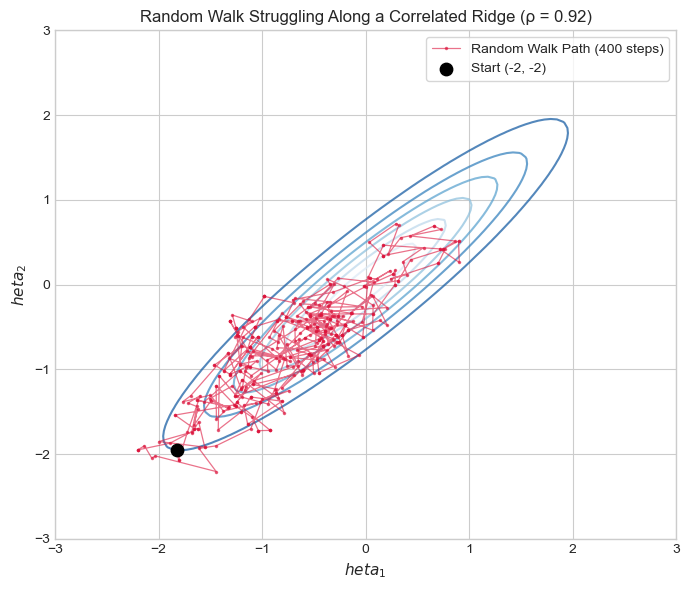

In [5]:
# Define a correlated 2D Gaussian posterior ridge (correlation rho = 0.92)
mu_2d = np.array([0.0, 0.0])
cov_2d = np.array([[1.0, 0.92], [0.92, 1.0]])
inv_cov_2d = np.linalg.inv(cov_2d)

def log_target_2d(theta):
    return -0.5 * theta @ inv_cov_2d @ theta

# Run Random-Walk Metropolis on the 2D ridge
n_steps = 1500
rw_chain = np.zeros((n_steps, 2))
curr = np.array([-2.0, -2.0])
prop_sd_2d = 0.25

for t in range(n_steps):
    prop = curr + rng.normal(0, prop_sd_2d, size=2)
    if np.log(rng.uniform(0, 1)) < (log_target_2d(prop) - log_target_2d(curr)):
        curr = prop
    rw_chain[t] = curr

# Visualize the random walk trajectory crawling along the ridge
x_grid, y_grid = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
pos = np.dstack((x_grid, y_grid))
z_density = stats.multivariate_normal(mu_2d, cov_2d).pdf(pos)

plt.figure(figsize=(7, 6))
plt.contour(x_grid, y_grid, z_density, levels=7, cmap="Blues_r", alpha=0.7)
plt.plot(rw_chain[:400, 0], rw_chain[:400, 1], color="crimson", alpha=0.6, lw=0.9, marker=".", markersize=3, label="Random Walk Path (400 steps)")
plt.scatter(rw_chain[0, 0], rw_chain[0, 1], color="black", s=80, zorder=5, label="Start (-2, -2)")
plt.title("Random Walk Struggling Along a Correlated Ridge (ρ = 0.92)")
plt.xlabel("$	heta_1$")
plt.ylabel("$	heta_2$")
plt.legend(frameon=True)
plt.show()

---
## 5. The Canonical PyMC & NUTS Benchmark

Now we turn to production Bayesian computation using **PyMC** and the **No-U-Turn Sampler (NUTS)**.

We benchmark NUTS on the exact conjugate Beta–Binomial problem ($y = 48, n = 80, a=2, b=2$), which has known ground truth $\operatorname{Beta}(50, 34)$.

In [6]:
# Model specification in PyMC
with pm.Model() as benchmark_model:
    # Prior: Beta(2, 2)
    theta = pm.Beta("theta", alpha=2, beta=2)
    
    # Likelihood: 48 successes out of 80 trials
    y_obs = pm.Binomial("y_obs", n=80, p=theta, observed=48)
    
    # Sample using NUTS with 4 independent chains
    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        random_seed=2026,
        return_inferencedata=True
    )

print("Sampling complete!")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [theta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


Sampling complete!


---
## 6. Passing the Minimum Computational Diagnostic Gate

Before interpreting any Bayesian model, run through the course diagnostic gate:

| Diagnostic | Screening Criterion | What It Tests |
|:---|:---|:---|
| **$\widehat{R}$ (Gelman–Rubin)** | $\widehat{R} \le 1.01$ | Do independent chains explore the same stationary distribution? |
| **Bulk ESS** | $\text{ESS}_{\text{bulk}} \ge 400$ | Is the effective draw count sufficient for posterior means/medians? |
| **Tail ESS** | $\text{ESS}_{\text{tail}} \ge 400$ | Are credible interval endpoints ($2.5\%, 97.5\%$) numerically stable? |
| **Divergences** | Exactly $0$ unresolved | Did the leapfrog integrator encounter regions of extreme curvature? |
| **Rank Plots** | Uniform bars across chains | Are chains well-mixed throughout the parameter support? |

=== ArviZ Diagnostic Summary ===
        mean     sd  hdi_3%  hdi_97%  mcse_mean  ess_bulk  ess_tail  r_hat
theta  0.594  0.052   0.491    0.687      0.001    1888.0    2516.0    1.0

Total Divergences: 0 (Pass criterion: 0)


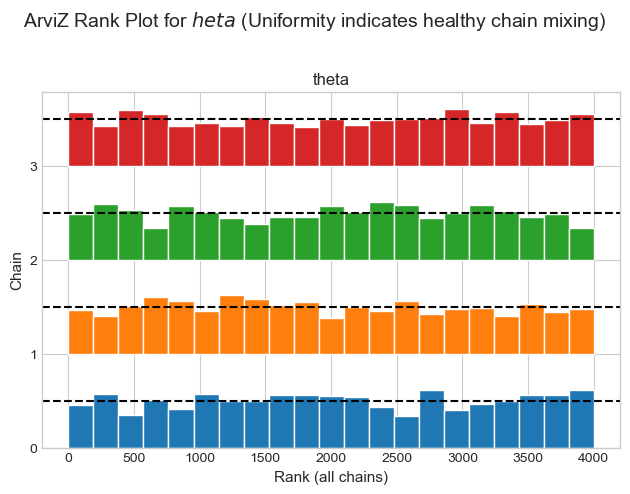

In [7]:
# 1. Numerical summary table
summary = az.summary(idata, var_names=["theta"], kind="all")
display_cols = ["mean", "sd", "hdi_3%", "hdi_97%", "mcse_mean", "ess_bulk", "ess_tail", "r_hat"]
print("=== ArviZ Diagnostic Summary ===")
print(summary[display_cols].to_string())

# 2. Divergence check
n_divergences = int(idata.sample_stats.diverging.values.sum())
print(f"\nTotal Divergences: {n_divergences} (Pass criterion: 0)")

# 3. Rank plot
az.plot_rank(idata, var_names=["theta"])
plt.suptitle("ArviZ Rank Plot for $	heta$ (Uniformity indicates healthy chain mixing)", y=1.02)
plt.show()

### Validating NUTS Against Analytic Closed Form

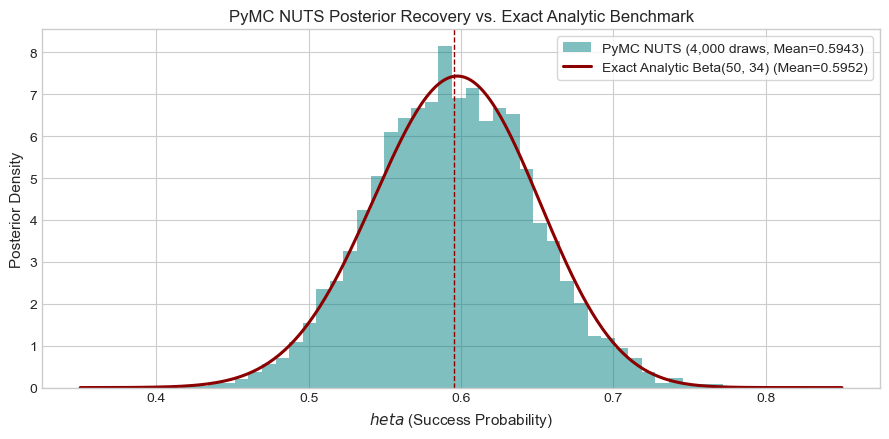

In [8]:
# Extract pooled posterior draws across all 4 chains
posterior_theta = idata.posterior["theta"].values.flatten()

# Comparison Plot
x_vals = np.linspace(0.35, 0.85, 300)
exact_pdf = stats.beta.pdf(x_vals, alpha_post, beta_post)

plt.figure(figsize=(9, 4.5))
plt.hist(posterior_theta, bins=40, density=True, alpha=0.5, color="teal", label=f"PyMC NUTS (4,000 draws, Mean={np.mean(posterior_theta):.4f})")
plt.plot(x_vals, exact_pdf, color="darkred", lw=2.2, label=f"Exact Analytic Beta(50, 34) (Mean={exact_mean:.4f})")
plt.axvline(exact_mean, color="darkred", ls="--", lw=1)
plt.title("PyMC NUTS Posterior Recovery vs. Exact Analytic Benchmark")
plt.xlabel("$	heta$ (Success Probability)")
plt.ylabel("Posterior Density")
plt.legend(frameon=True)
plt.show()

---
## 7. Guided Practice & Laboratory Reflection

### Challenge 1: Estimand-Specific Monte Carlo Error
Compute the posterior probability that $\theta > 0.65$ using the PyMC draws:

$$p_{\text{target}} = \Pr(\theta > 0.65 \mid y) = \mathbb{E}[\mathbb{I}(\theta > 0.65) \mid y].$$

Calculate its empirical Monte Carlo Standard Error using the indicator variance:

$$\operatorname{MCSE}(p) = \sqrt{\frac{p(1 - p)}{\text{ESS}_{\text{tail}}}}.$$

In [9]:
indicator_draws = (posterior_theta > 0.65).astype(float)
prob_est = np.mean(indicator_draws)

# Exact tail probability from Beta(50, 34)
exact_prob = 1.0 - stats.beta.cdf(0.65, alpha_post, beta_post)

ess_tail = float(summary["ess_tail"].iloc[0])
mcse_prob = np.sqrt((prob_est * (1.0 - prob_est)) / ess_tail)

print(f"Target Estimand: Pr(θ > 0.65 | y)")
print(f"Exact Analytic Probability: {exact_prob:.4f}")
print(f"PyMC MCMC Estimate:        {prob_est:.4f} ± {mcse_prob:.4f} (MCSE)")
print(f"Absolute Error:             {abs(prob_est - exact_prob):.4f}")

Target Estimand: Pr(θ > 0.65 | y)
Exact Analytic Probability: 0.1530
PyMC MCMC Estimate:        0.1410 ± 0.0069 (MCSE)
Absolute Error:             0.0120


### Reflection Questions

1. **Why does high acceptance rate NOT imply high sampling efficiency?**  
   *In Experiment 3, the $\sigma = 0.01$ chain had a $98\%$ acceptance rate, but its autocorrelation decayed very slowly. Why?*

2. **Why do we need 4 chains?**  
   *Can a single chain diagnose multimodality or convergence failure using $\widehat{R}$?*

3. **What is the consequence of 1 divergence?**  
   *If an MCMC fit reports $\widehat{R} = 1.00$ and large ESS, but 3 divergences occur, can you interpret the posterior?*